In [1]:
import os
import sys
import argparse
import random

import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from BA import oh_binary_accuracy

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=500, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
def kPCA(X, Y, eps=1e-6):
    a = X @ X.T + Y @ Y.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [4]:
def kPCA_1V(X, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [5]:
def run_model_batch(img_batch, label_batch):
    x_en = net1(img_batch)
    y_en = net2(label_batch)

    h, _ = kPCA(x_en, y_en)
    U = torch.mm(x_en.t(), h)
    V = torch.mm(y_en.t(), h)

    x_tilde = net3(torch.mm(h, U.t()))
    y_tilde = net4(torch.mm(h, V.t()))
    return x_tilde, y_tilde

In [6]:
def run_model_batch_1V(img_batch):
    x_en = net1_1V(img_batch)

    h, _ = kPCA_1V(x_en)
    U = torch.mm(x_en.t(), h)

    x_tilde = net3_1V(torch.mm(h, U.t()))
    return x_tilde

In [7]:
def create_adversarial_batch(in_images, in_labels, epsilon=0.1):
    net1.zero_grad()
    net2.zero_grad()
    net3.zero_grad()
    net4.zero_grad()

    adv_images = in_images.clone().detach().to(opt.device)
    adv_images.requires_grad_(True)
    in_labels = in_labels.to(opt.device)

    out_images, _ = run_model_batch(adv_images, in_labels)

    loss = torch.nn.functional.mse_loss(out_images, in_images)
    loss.backward()

    signed_grad = adv_images.grad.sign()
    adv_images = adv_images + epsilon * signed_grad
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach(), signed_grad.detach()

In [8]:
def create_adversarial_batch_1V(in_images, epsilon=0.1):
    net1_1V.zero_grad()
    net3_1V.zero_grad()
    
    adv_images = in_images.clone().detach().to(opt.device)
    adv_images.requires_grad_(True)

    out_images = run_model_batch_1V(adv_images)

    loss = torch.nn.functional.mse_loss(out_images, in_images)
    loss.backward()

    signed_grad = adv_images.grad.sign()
    adv_images = adv_images + epsilon * signed_grad
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach(), signed_grad.detach()

In [9]:
_, xtest, _, _ = get_mnist_dataloader(args=opt)

In [10]:
model = torch.load('out/Final.tar', weights_only=False)
model_1V = torch.load('out/Final-1V.tar', weights_only=False)

net1 = model['net1']
net2 = model['net2']
net3 = model['net3']
net4 = model['net4']

net1_1V = model_1V['net1']
net3_1V = model_1V['net3']

net1.eval()
net2.eval()
net3.eval()
net4.eval()
net1_1V.eval()
net3_1V.eval()

Net3(
  (fc1): Linear(in_features=48, out_features=3136, bias=True)
  (conv2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv1): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
)

## Attack
### Clean Reconstruction

In [11]:
datax, datay = next(iter(xtest))   # full first test batch
datax = datax.to(opt.device).double()
datay = datay.to(opt.device).double()

# originals for plotting
in_data_x_test = datax[:10].detach().cpu().numpy()
in_data_y_test = datay[:10].detach().cpu().numpy()

# clean reconstruction with full-batch kPCA
with torch.no_grad():
    x_en = net1(datax)
    y_en = net2(datay)
    x_en_1V = net1_1V(datax)

    _h, _ = kPCA(x_en, y_en)
    _h_1V, _ = kPCA_1V(x_en_1V)

    U = torch.mm(x_en.t(), _h)
    V = torch.mm(y_en.t(), _h)
    U_1V = torch.mm(x_en_1V.t(), _h_1V)

    x_tilde = net3(torch.mm(_h, U.t()))
    y_tilde = net4(torch.mm(_h, V.t()))
    x_tilde_1V = net3_1V(torch.mm(_h_1V, U_1V.t()))

out_data_x_test = x_tilde.detach().cpu().numpy()
out_data_x_test_1V = x_tilde_1V.detach().cpu().numpy()
out_data_y_test = y_tilde.detach().cpu().numpy()

### Attacked Reconstruction

In [12]:
epsilon = 0.1
adv_batch, _ = create_adversarial_batch(datax, datay, epsilon=epsilon)
adv_batch_1V, _ = create_adversarial_batch_1V(datax, epsilon=epsilon)

with torch.no_grad():
    adv_x_tilde, adv_y_tilde = run_model_batch(adv_batch, datay)
    adv_x_tilde_1V = run_model_batch_1V(adv_batch_1V)

adv_data_x_test = adv_batch[:10].detach().cpu().numpy()                 # The attacked input

adv_out_data_x_test = adv_x_tilde[:10].detach().cpu().numpy()           # The attacked image reconstruction
adv_out_data_x_test_1V = adv_x_tilde_1V[:10].detach().cpu().numpy()     # The attacked image reconstruction for 1V model
adv_out_data_y_test = adv_y_tilde[:10].detach().cpu().numpy()           # The attacked label reconstruction

perturbation_test = (adv_batch[:10] - datax[:10]).detach().cpu().numpy()

### Loss Calculation

In [13]:
recon_loss = torch.nn.MSELoss(reduction='mean')
B = datax.size(0)

#! Clean batch losses                                                         ---
clean_digit_loss = recon_loss(x_tilde.view(B, -1), datax.view(B, -1))       # Digit reconstruction loss
clean_label_loss = 1 - oh_binary_accuracy(                                  # Label reconstruction loss (accuracy-based)
    datay.detach().cpu().numpy(),
    y_tilde.view(B, -1).detach().cpu().numpy()
)

clean_total_loss = (clean_digit_loss.item() + clean_label_loss) / 2         # Total loss as average of the two

#! Adversarial batch losses                                                   ---
adv_digit_loss = recon_loss(adv_x_tilde.view(B, -1), datax.view(B, -1))     # Digit reconstruction
adv_label_loss = 1 - oh_binary_accuracy(                                    # Label reconstruction loss (accuracy-based)
    datay.detach().cpu().numpy(),
    adv_y_tilde.view(B, -1).detach().cpu().numpy()
)

adv_total_loss = (adv_digit_loss.item() + adv_label_loss) / 2

In [14]:
# Loss values for the 1V model
clean_digit_loss_1V = recon_loss(x_tilde_1V.view(B, -1), datax.view(B, -1))
adv_digit_loss_1V = recon_loss(adv_x_tilde_1V.view(B, -1), datax.view(B, -1))

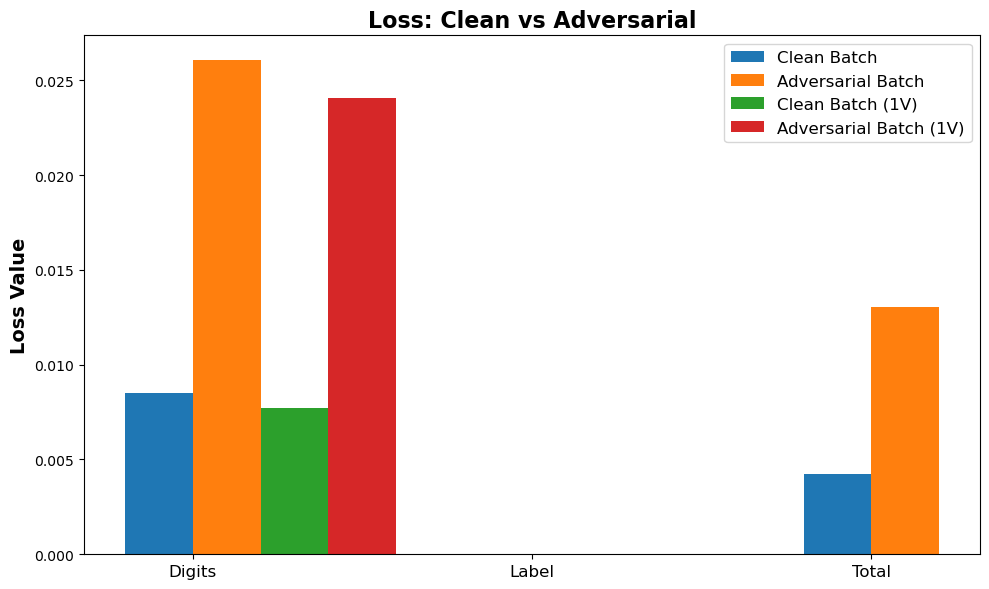

In [15]:
categories = ['Digits', 'Label', 'Total']
clean_losses = [clean_digit_loss.item(), clean_label_loss.item(), clean_total_loss]
adv_losses   = [adv_digit_loss.item(),   adv_label_loss.item(),   adv_total_loss]

x = list(range(len(categories)))
width = 0.2

plt.figure(figsize=(10, 6))

# Main bars for all categories
plt.bar([i - width/2 for i in x], clean_losses, width=width, label='Clean Batch', color='tab:blue')
plt.bar([i + width/2 for i in x], adv_losses,   width=width, label='Adversarial Batch', color='tab:orange')

# Extra 1V bars only for the first category ("Digits")
x_digits = x[0]
plt.bar(x_digits + 1.5*width, clean_digit_loss_1V.item(), width=width, label='Clean Batch (1V)', color='tab:green')
plt.bar(x_digits + 2.5*width, adv_digit_loss_1V.item(),   width=width, label='Adversarial Batch (1V)', color='tab:red')

plt.xticks(x, categories, fontsize=12)
plt.title('Loss: Clean vs Adversarial', fontsize=16, weight='bold')
plt.ylabel('Loss Value', fontsize=14, weight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

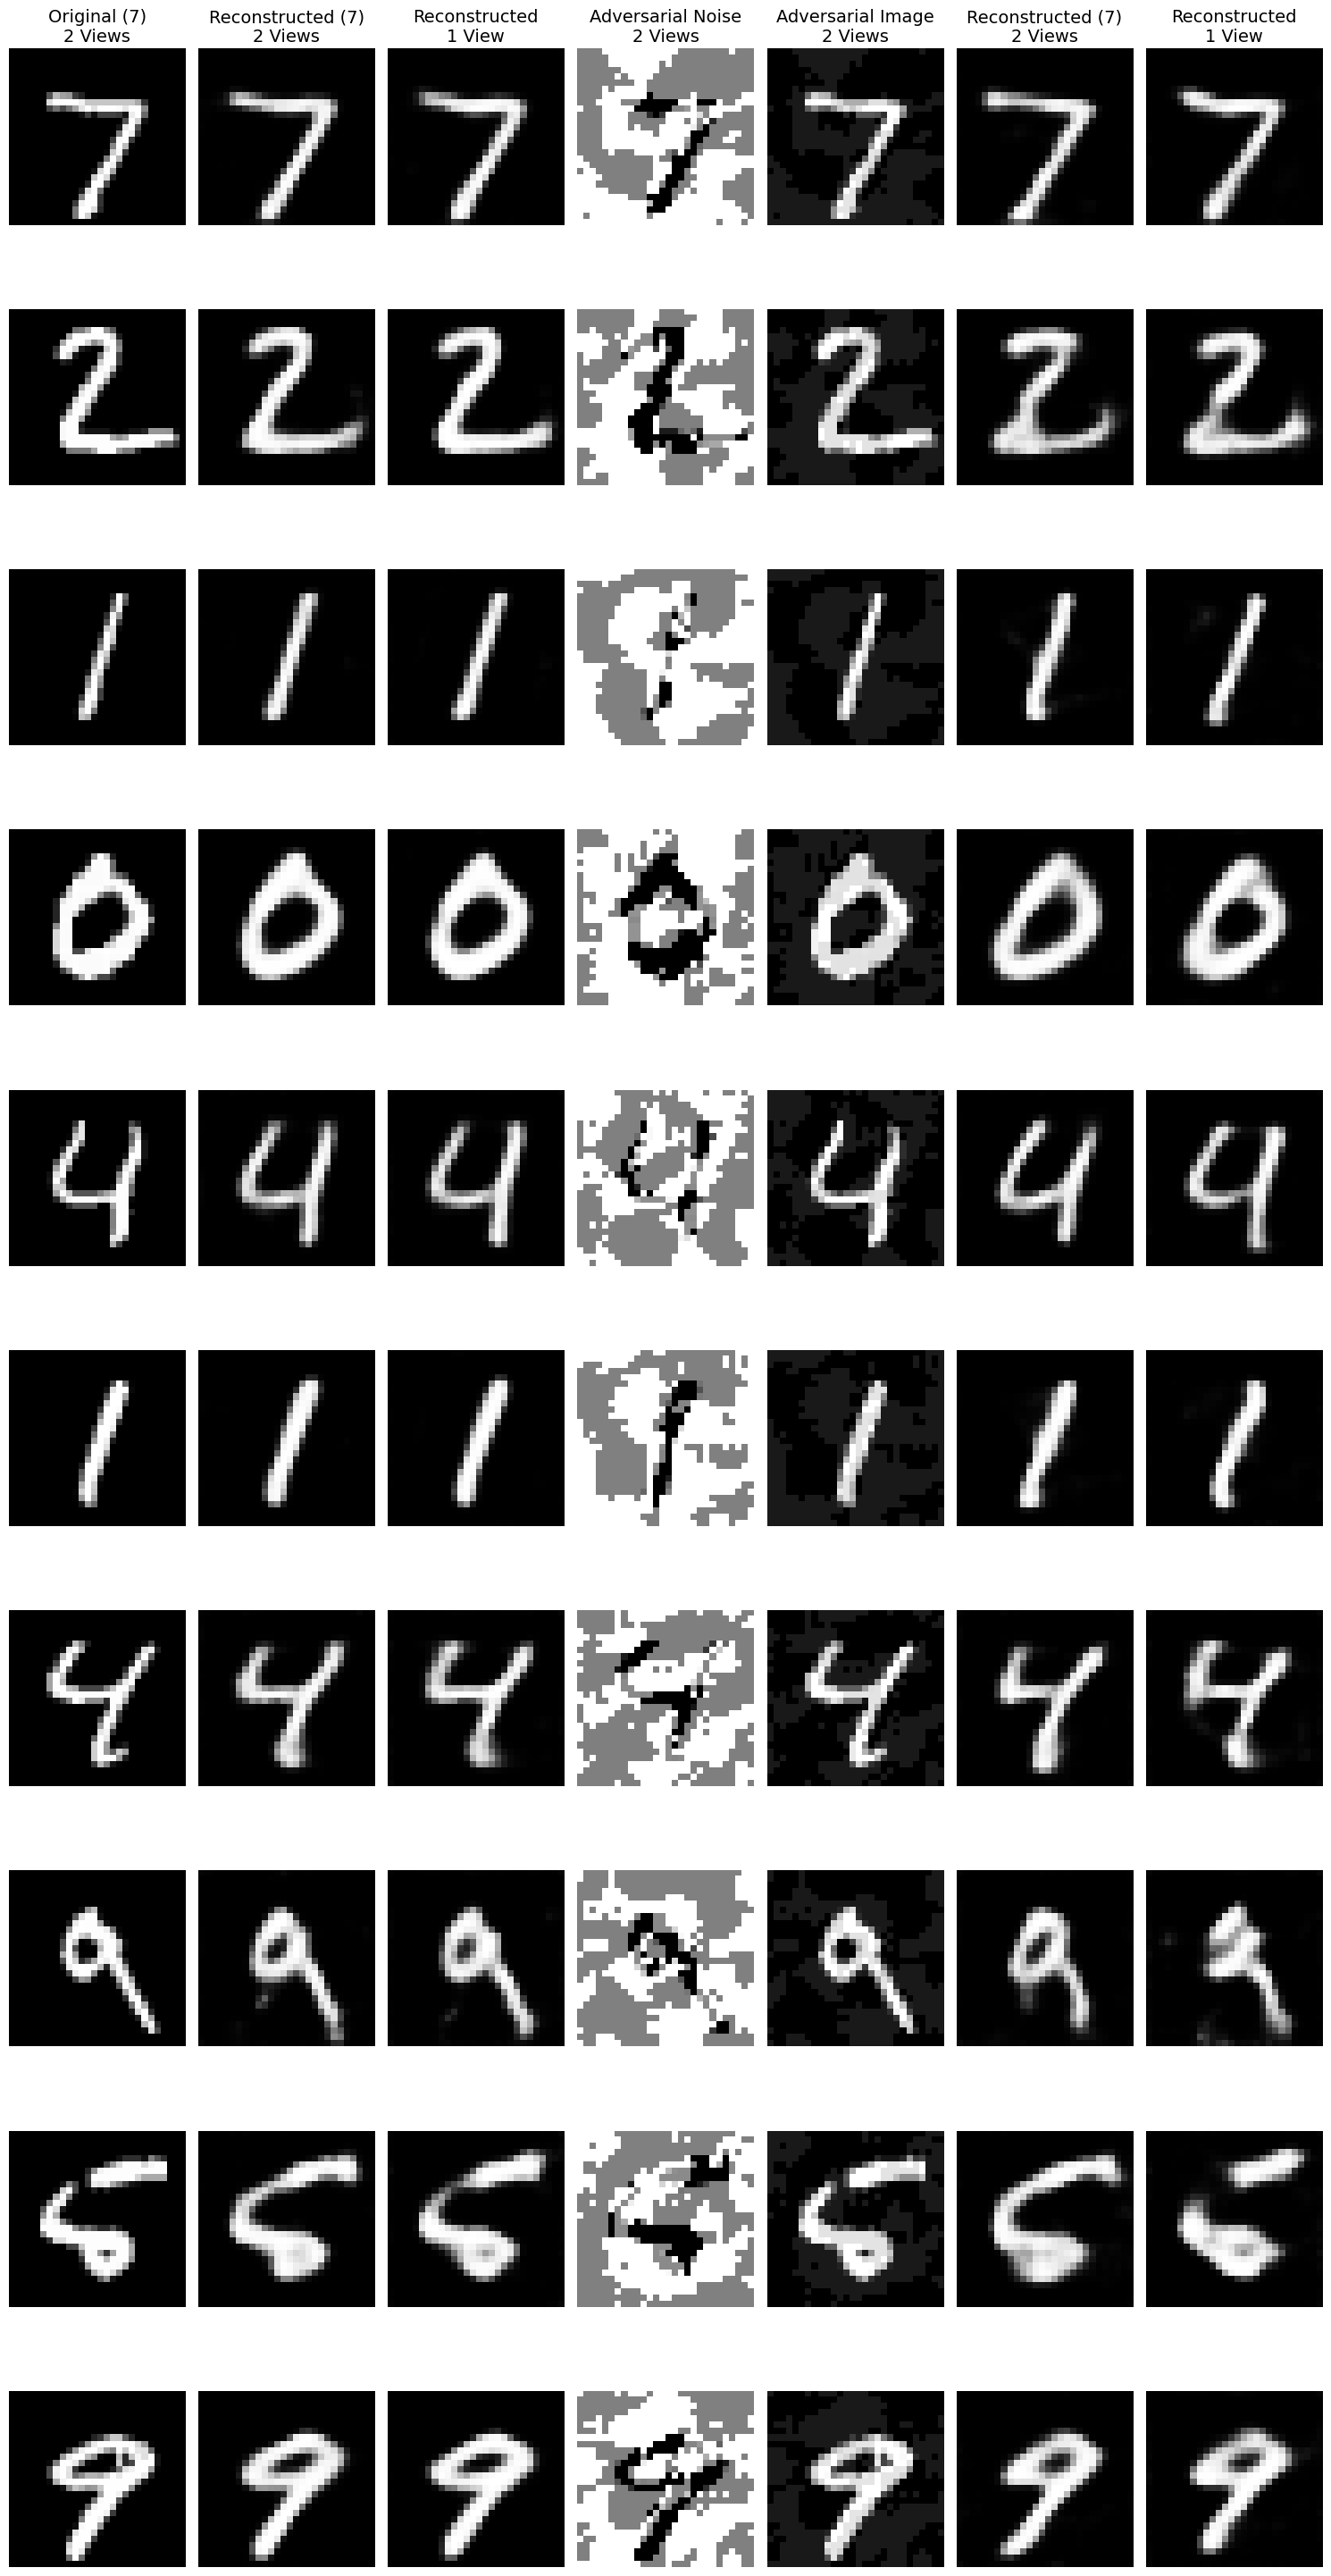

In [16]:
fig, axes = plt.subplots(10, 7, figsize=(15, 30))

for i in range(10):
    # original
    if i == 0:
        axes[i, 0].set_title(f'Original ({datay[i].argmax().item()})\n2 Views', fontsize=14)
    axes[i, 0].imshow(datax[i].squeeze().detach().cpu().numpy(), cmap='gray')
    axes[i, 0].axis('off')

    # clean reconstruction
    if i == 0:
        axes[i, 1].set_title(f'Reconstructed ({out_data_y_test[i].argmax()})\n2 Views', fontsize=14)
    axes[i, 1].imshow(out_data_x_test[i].reshape(28, 28), cmap='gray')
    axes[i, 1].axis('off')

    # 1 view reconstruction
    if i == 0:
        axes[i, 2].set_title('Reconstructed\n1 View', fontsize=14)
    axes[i, 2].imshow(out_data_x_test_1V[i].reshape(28, 28), cmap='gray')
    axes[i, 2].axis('off')

    # perturbation
    if i == 0:
        axes[i, 3].set_title('Adversarial Noise\n2 Views', fontsize=14)
    axes[i, 3].imshow(perturbation_test[i].reshape(28, 28), cmap='gray')
    axes[i, 3].axis('off')

    # adversarial image
    if i == 0:
        axes[i, 4].set_title('Adversarial Image\n2 Views', fontsize=14)
    axes[i, 4].imshow(adv_data_x_test[i].reshape(28, 28), cmap='gray')
    axes[i, 4].axis('off')

    # adversarial reconstruction
    if i == 0:
        axes[i, 5].set_title(f'Reconstructed ({adv_out_data_y_test[i].argmax()})\n2 Views', fontsize=14)
    axes[i, 5].imshow(adv_out_data_x_test[i].reshape(28, 28), cmap='gray')
    axes[i, 5].axis('off')

    # adversarial reconstruction for 1V model
    if i == 0:
        axes[i, 6].set_title('Reconstructed\n1 View', fontsize=14)
    axes[i, 6].imshow(adv_out_data_x_test_1V[i].reshape(28, 28), cmap='gray')
    axes[i, 6].axis('off')

plt.tight_layout()
plt.show()